In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
FIG = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

# Phase 3 — Attribute extraction (NER)

Four methods scored on WDC-PAVE test titles (354 offers). Computed by `python -m src.extract ...`.

## 1. F1 per method and attribute (strict match)

In [2]:
f1 = pd.read_csv(ROOT/'reports'/'phase3_f1.csv')
strict = f1[f1['match']=='strict'].pivot(index='attribute', columns='method', values='f1')[['rules','gliner','llm','distilled']]
strict

method,rules,gliner,llm,distilled
attribute,,,,
MACRO,0.340,0.505,0.592,0.165
brand,0.409,0.769,0.844,0.413
colour,0.730,0.697,0.701,0.311
pack_count,0.309,0.637,0.408,0.000
product_type,0.089,0.186,0.526,0.060
quantity,0.163,0.234,0.481,0.042


In [3]:
f1[f1['match']=='lenient'].pivot(index='attribute', columns='method', values='f1')[['rules','gliner','llm','distilled']]

method,rules,gliner,llm,distilled
attribute,,,,
MACRO,0.443,0.592,0.683,0.273
brand,0.484,0.846,0.963,0.590
colour,0.905,0.813,0.739,0.525
pack_count,0.309,0.637,0.408,0.000
product_type,0.324,0.346,0.816,0.209
quantity,0.192,0.319,0.491,0.042


In [4]:
f1[f1['match']=='strict'][['method','attribute','precision','recall','f1','gold_n']]

,method,attribute,precision,recall,f1,gold_n
0,rules,brand,0.583,0.315,0.409,346
1,rules,product_type,0.078,0.102,0.089,254
2,rules,colour,0.746,0.714,0.730,70
3,rules,quantity,0.140,0.195,0.163,87
4,rules,pack_count,0.231,0.467,0.309,46
5,rules,MACRO,0.356,0.359,0.340,803
12,gliner,brand,0.790,0.749,0.769,346
13,gliner,product_type,0.177,0.197,0.186,254
14,gliner,colour,0.635,0.771,0.697,70
15,gliner,quantity,0.218,0.253,0.234,87


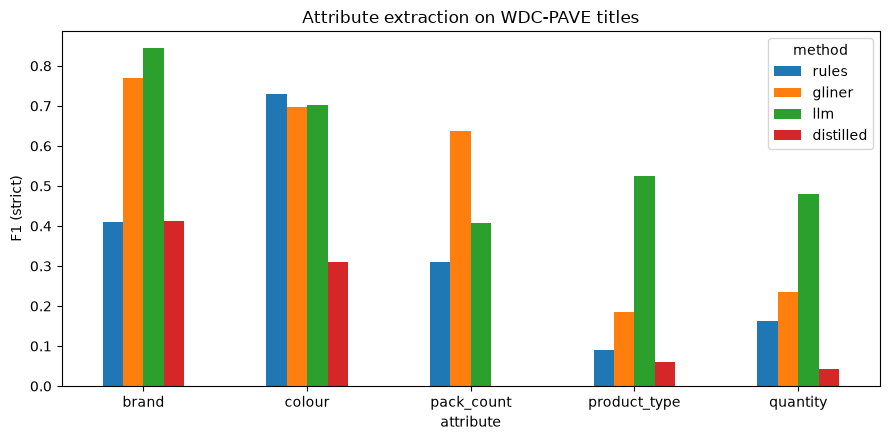

In [5]:
ax = strict.drop('MACRO').plot.bar(figsize=(9, 4.5)); ax.set_ylabel('F1 (strict)'); ax.set_title('Attribute extraction on WDC-PAVE titles')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(FIG/'phase3_f1.png', dpi=120)

## 2. Speed

In [6]:
import json; pd.DataFrame(json.load(open(ROOT/'reports'/'phase3_timing.json'))).T

,seconds,names,names_per_second
rules,0.79,354.0,449.78
gliner,25.22,354.0,14.04
llm,4791.03,354.0,0.07
distilled,0.37,354.0,950.55


## 3. Distillation learning curve (teacher = GLiNER)

In [7]:
pd.read_csv(ROOT/'reports'/'phase3_learning_curve.csv')

,llm_labelled_names,train,dev,skipped_no_span,train_seconds,brand,product_type,colour,quantity,pack_count,MACRO
0,250,220,24,6,16.1,0.289,0.034,0.101,0.017,0.0,0.088
1,500,441,49,10,21.3,0.345,0.032,0.147,0.015,0.0,0.108
2,1000,878,97,25,41.9,0.422,0.053,0.215,0.035,0.0,0.145
3,2000,1760,195,45,84.4,0.413,0.060,0.311,0.042,0.0,0.165


## 4. displaCy: distilled spaCy NER and rule-based EntityRuler on PAVE titles

In [8]:
import spacy
from spacy import displacy
from src import extract as X
titles = X.pave_test()['title'].sample(8, random_state=1).tolist()
ner = spacy.load(ROOT/'models'/'ner_distilled')
html_ner = displacy.render(list(ner.pipe(titles)), style='ent', page=True, jupyter=False)
html_rules = displacy.render(list(X.get_rule_nlp().pipe(titles)), style='ent', page=True, jupyter=False)
(FIG/'phase3_displacy_distilled.html').write_text(html_ner, encoding='utf-8')
(FIG/'phase3_displacy_rules.html').write_text(html_rules, encoding='utf-8')
displacy.render(list(ner.pipe(titles)), style='ent', jupyter=True)

D:\College\NLP_NOTES\NLP LAB CA\.venv\Lib\site-packages\spacy\displacy\__init__.py:214: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


In [9]:
displacy.render(list(X.get_rule_nlp().pipe(titles)), style='ent', jupyter=True)

D:\College\NLP_NOTES\NLP LAB CA\.venv\Lib\site-packages\spacy\displacy\__init__.py:214: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


## 5. Side-by-side predictions

In [10]:
g = X.pave_test()
rows = []
preds = {m: X.load_preds(m) for m in ['rules','gliner','llm','distilled']}
for k in [0, 5, 17, 40, 77, 120]:
    for m, p in preds.items():
        rows.append({'title': g['title'][k][:70], 'method': m, **{a: p[k].get(a) for a in ['brand','product_type','colour','quantity','pack_count']}})
    rows.append({'title': g['title'][k][:70], 'method': 'GOLD', **{a: '; '.join(sorted(g[a][k])) for a in ['brand','product_type','colour','quantity','pack_count']}})
pd.DataFrame(rows)

,title,method,brand,product_type,colour,quantity,pack_count
0,"435952-B21 HP Xeon E5335 2.0GHz DL360 G5"" Null",rules,HP,Null,NaN,NaN,None
1,"435952-B21 HP Xeon E5335 2.0GHz DL360 G5"" Null",gliner,HP,DL360 G5,NaN,NaN,None
2,"435952-B21 HP Xeon E5335 2.0GHz DL360 G5"" Null",llm,HP,Xeon E5335,NaN,NaN,None
3,"435952-B21 HP Xeon E5335 2.0GHz DL360 G5"" Null",distilled,435952,NaN,Null,NaN,None
4,"435952-B21 HP Xeon E5335 2.0GHz DL360 G5"" Null",GOLD,HP,,,,
5,"Regal Leather Business Card Binder, 120 Cap, 2 x 3 1/2 Cards, Black Bi",rules,NaN,Business Card Binder,Black,NaN,2.0
6,"Regal Leather Business Card Binder, 120 Cap, 2 x 3 1/2 Cards, Black Bi",gliner,Samsill,Regal Leather Business Card Binder,Black,NaN,None
7,"Regal Leather Business Card Binder, 120 Cap, 2 x 3 1/2 Cards, Black Bi",llm,Samsill,Business Card Binder,Black,120 Cap,None
8,"Regal Leather Business Card Binder, 120 Cap, 2 x 3 1/2 Cards, Black Bi",distilled,Regal Leather,NaN,Black Binder by Samsill,2 x 3 1/2,None
9,"Regal Leather Business Card Binder, 120 Cap, 2 x 3 1/2 Cards, Black Bi",GOLD,Samsill,Business Card Binder,Black,120,
